<div style="background:linear-gradient(135deg,#134e4a 0%,#115e59 55%,#5eead4 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#99f6e4;font-weight:700;text-transform:uppercase">Chapter 203 &middot; Capstone 40 &middot; Survival Analysis</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Time to Event</div>
  <div style="font-size:15px;color:#99f6e4;max-width:820px;line-height:1.6">Fifty-seven percent of these employees have not left yet, so they have no tenure to average. The number HR reports leaves them out and understates how long people stay by a third. Two standard summaries then agree that remote work makes no difference, and both are wrong in the same way.</div>
</div>

In [1]:
import subprocess, sys
try: import lifelines
except ImportError: subprocess.run([sys.executable, "-m", "pip", "install", "-q", "lifelines"])
import numpy as np, pandas as pd, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt, statsmodels.api as sm
from lifelines import KaplanMeierFitter, CoxPHFitter, CoxTimeVaryingFitter
from lifelines.statistics import multivariate_logrank_test, logrank_test, proportional_hazard_test
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
TL, DK, LT, MUT, GD, RD = "#115e59", "#134e4a", "#5eead4", "#94a3b8", "#047857", "#dc2626"

BASE_URL = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-survival-analysis-time-to-event.xlsx"
def load(sheet):
    try:    return pd.read_excel("../../data/" + fn, sheet_name=sheet)
    except FileNotFoundError: return pd.read_excel(BASE_URL + fn, sheet_name=sheet)
raw   = load("Data")
notes = load("Notes")
CUTOFF = pd.Timestamp("2026-01-01")
print("rows in the HR extract:", len(raw))
raw.head()

rows in the HR extract: 3211


,employee_id,department,work_mode,level,salary_percentile,manager_changes,hire_date,exit_date,exit_type
0,E10000,Platform,hybrid,5,57,0,2025-01-01,NaN,NaN
1,E10001,Platform,onsite,5,29,1,2025-05-01,NaN,NaN
2,E10002,Sales,onsite,5,69,0,2022-07-01,2025-04-01,voluntary
3,E10003,Engineering,remote,1,63,0,2021-01-01,2022-08-01,voluntary
4,E10004,Customer Support,remote,2,27,1,2025-05-01,2025-08-01,involuntary


## Step 1 &middot; The brief

In [2]:
for line in notes.Notes.fillna(""):
    print(line)

EMPLOYEE RETENTION. Everyone hired between January 2020 and the cut-off of 1 January 2026.

THE QUESTION. How long do people stay, which teams keep them, and does working remotely
make any difference? A remote-work policy decision is waiting on the last one.

WHAT MAKES THIS DIFFERENT. Most of the people in this file have not left. They have no
tenure to average, but they are not missing either: someone hired thirty months ago and
still here has told us their tenure is AT LEAST thirty months. The number HR currently
reports, mean tenure among people who left, uses none of that and is not an estimate of
how long people stay.

WHAT IS IN THE EXPORT, as it arrived:
 - eleven employees appear twice
 - Operations was renamed from Ops in July 2022 and both spellings are present
 - nine rows have an exit date before the hire date
 - work_mode is blank for some employees
 - Platform was created in July 2024, so nobody in it has more than eighteen months
   of service. Read its numbers carefull

**The sentence that matters is the one about people who have not left.**

An employee hired thirty months ago who is still here has not told us their tenure. But they have not told us nothing either: they have told us their tenure is *at least* thirty months. That is a real observation with a real value, and it is called a **censored** observation.

The previous chapter was about rows with a gap in them. This looks like the same problem and is not. A missing BMI is a number that exists and was not recorded. A censored tenure is a number that **does not exist yet**. You cannot impute it, because there is nothing yet to impute, and you must not drop it, because it carries information about everyone who lasted that long.

Survival analysis is the set of tools that use a lower bound as evidence.

## Step 2 &middot; Cleaning

In [3]:
d = raw.drop_duplicates("employee_id").reset_index(drop=True)
print(f"duplicate employees   {len(raw)-len(d)} dropped -> {len(d)}")

print(f"departments as written: {sorted(raw.department.unique())}")
d["department"] = d.department.replace({"Ops": "Operations"})
print(f"after folding Ops:      {sorted(d.department.unique())}")

d["hire_date"] = pd.to_datetime(d.hire_date); d["exit_date"] = pd.to_datetime(d.exit_date)
bad = d.exit_date.notna() & (d.exit_date < d.hire_date)
print(f"exit before hire      {bad.sum()} rows dropped")
d = d[~bad].reset_index(drop=True)

print(f"work_mode blank       {d.work_mode.isna().sum()} kept as their own category")
d["work_mode"] = d.work_mode.fillna("unrecorded")

d["tenure_months"] = ((d.exit_date.fillna(CUTOFF) - d.hire_date).dt.days/30.44).round(1)
d = d[d.tenure_months > 0].reset_index(drop=True)
d["left"] = (d.exit_type == "voluntary").astype(int)

print(f"\nanalysis frame        {len(d)} employees, tenure {d.tenure_months.min():.1f} "
      f"to {d.tenure_months.max():.1f} months")
print(f"  resigned            {d.left.sum()} ({d.left.mean():.1%})")
print(f"  let go              {(d.exit_type=='involuntary').sum()}")
print(f"  still employed      {d.exit_type.isna().sum()}")
print(f"  CENSORED for this question: {1-d.left.mean():.1%}")

duplicate employees   11 dropped -> 3200
departments as written: ['Customer Support', 'Engineering', 'Operations', 'Ops', 'Platform', 'Sales']
after folding Ops:      ['Customer Support', 'Engineering', 'Operations', 'Platform', 'Sales']
exit before hire      9 rows dropped
work_mode blank       58 kept as their own category

analysis frame        3191 employees, tenure 0.9 to 72.0 months
  resigned            1375 (43.1%)
  let go              83
  still employed      1733
  CENSORED for this question: 56.9%


**The 58 employees with no work mode recorded are kept.** Dropping them would be the previous chapter's mistake in a new costume, and they are not obviously like anyone else. Giving them their own category keeps them in every count and lets the model say whether they differ.

**Involuntary exits are counted as censored here, and that is an assumption.** Someone let go in month 14 did not resign, so the event we are modeling did not happen to them, and what we know is that they had not resigned by month 14. Treating that as censoring assumes being let go is unrelated to being about to resign. Step 11 says why that is worth stating out loud.

## Step 3 &middot; First look

In [4]:
print(f"hires per year        {d.hire_date.dt.year.value_counts().sort_index().to_dict()}")
print(f"follow-up available   median {d.tenure_months.median():.1f} months, "
      f"quartiles {d.tenure_months.quantile(.25):.1f} to {d.tenure_months.quantile(.75):.1f}")
print(f"resignation rate      {d.left.mean():.1%} overall, by department:")
print("  " + ", ".join(f"{k} {v:.0%}" for k, v in d.groupby('department').left.mean().items()))

hires per year        {2020: 482, 2021: 475, 2022: 447, 2023: 484, 2024: 596, 2025: 707}
follow-up available   median 18.0 months, quartiles 9.0 to 30.0
resignation rate      43.1% overall, by department:
  Customer Support 60%, Engineering 40%, Operations 44%, Platform 5%, Sales 54%


**What this shows.** Nobody in the file can have more than six years of service because the window only opened in 2020, and half of everyone has under a year and a half of follow-up. Raw resignation rates already differ a lot by department, but a department's rate depends on how long its people have been around, which is the trap in the next two steps.

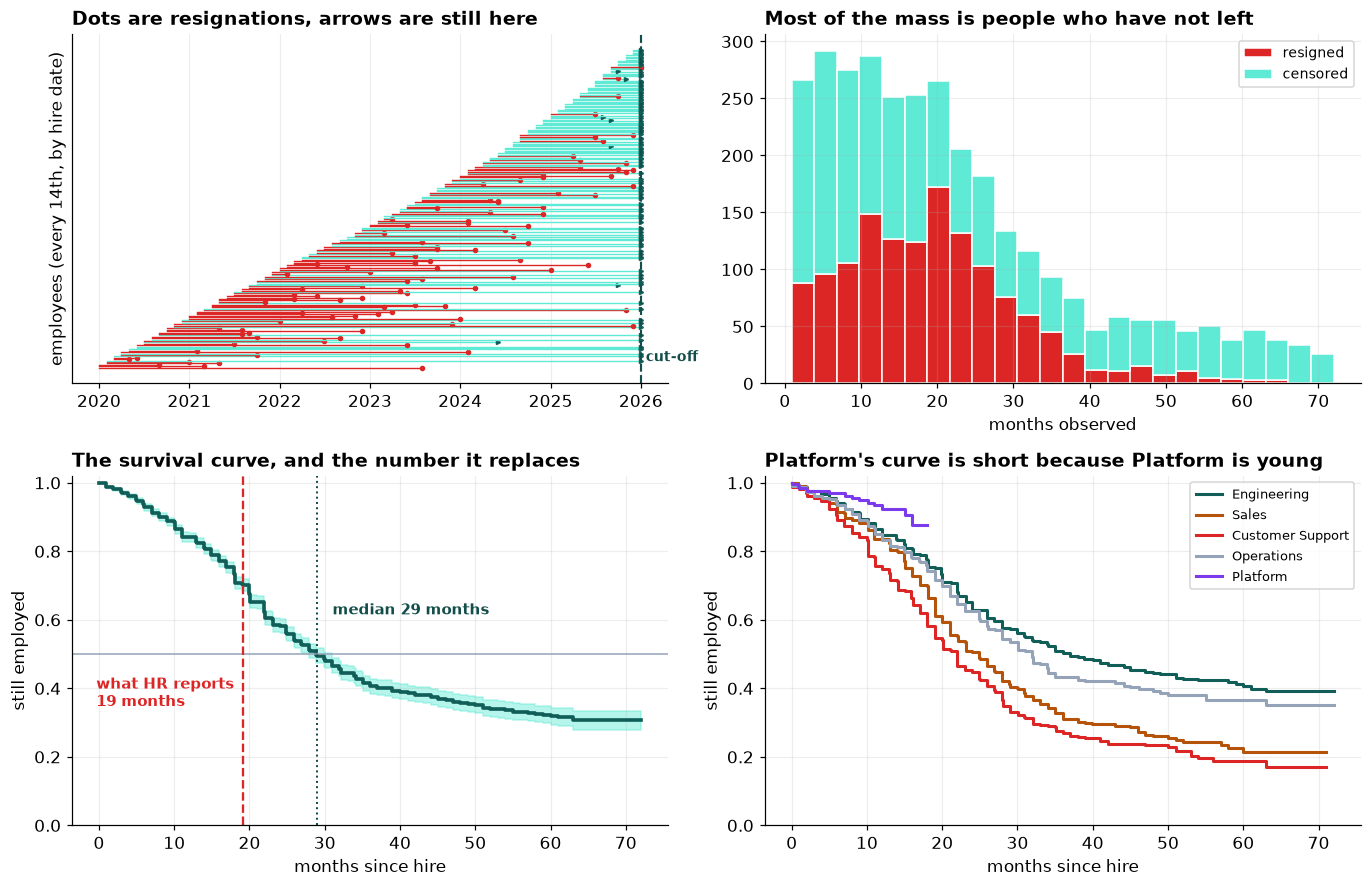

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(12.6, 8.2))

s = d.sort_values("hire_date").reset_index(drop=True)
sub = s.iloc[::14].reset_index(drop=True)
for i, r in sub.iterrows():
    end = r.exit_date if pd.notna(r.exit_date) else CUTOFF
    ax[0,0].plot([r.hire_date, end], [i, i], color=RD if r.left else LT, lw=0.9)
    if r.left: ax[0,0].plot(end, i, "o", color=RD, ms=2.6)
    else:      ax[0,0].plot(end, i, ">", color=TL, ms=2.6)
ax[0,0].axvline(CUTOFF, color=DK, lw=1.4, ls="--")
ax[0,0].text(CUTOFF, len(sub)*0.02, " cut-off", fontsize=9, color=DK, fontweight="bold")
ax[0,0].set_ylabel("employees (every 14th, by hire date)"); ax[0,0].set_yticks([])
ax[0,0].set_title("Dots are resignations, arrows are still here")

ax[0,1].hist([d.tenure_months[d.left == 1], d.tenure_months[d.left == 0]], bins=24, stacked=True,
             color=[RD, LT], edgecolor="white", label=["resigned", "censored"])
ax[0,1].set_xlabel("months observed"); ax[0,1].legend(fontsize=9)
ax[0,1].set_title("Most of the mass is people who have not left")

km = KaplanMeierFitter().fit(d.tenure_months, d.left)
ax[1,0].step(km.survival_function_.index, km.survival_function_.values[:,0], color=TL, lw=2.4)
ci = km.confidence_interval_survival_function_
ax[1,0].fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1], color=LT, alpha=0.45, step="pre")
med = float(km.median_survival_time_)
ax[1,0].axhline(0.5, color=MUT, lw=1); ax[1,0].axvline(med, color=DK, lw=1.3, ls=":")
ax[1,0].annotate(f"median {med:.0f} months", (med, 0.5), textcoords="offset points",
                 xytext=(10, 26), fontsize=9.5, color=DK, fontweight="bold")
naive = d.tenure_months[d.left == 1].mean()
ax[1,0].axvline(naive, color=RD, lw=1.5, ls="--")
ax[1,0].annotate(f"what HR reports\n{naive:.0f} months", (naive, 0.5), textcoords="offset points",
                 xytext=(-96, -34), fontsize=9.5, color=RD, fontweight="bold")
ax[1,0].set_xlabel("months since hire"); ax[1,0].set_ylabel("still employed"); ax[1,0].set_ylim(0, 1.02)
ax[1,0].set_title("The survival curve, and the number it replaces")

for dep, c in zip(["Engineering","Sales","Customer Support","Operations","Platform"],
                  [TL, "#b45309", RD, MUT, "#7c3aed"]):
    sd = d[d.department == dep]
    k = KaplanMeierFitter().fit(sd.tenure_months, sd.left)
    ax[1,1].step(k.survival_function_.index, k.survival_function_.values[:,0], lw=2, color=c, label=dep)
ax[1,1].set_xlabel("months since hire"); ax[1,1].set_ylabel("still employed")
ax[1,1].legend(fontsize=8.5); ax[1,1].set_ylim(0, 1.02)
ax[1,1].set_title("Platform's curve is short because Platform is young")
plt.tight_layout(); plt.show()

**Top left.** A sample of employees drawn as lines from hire to either a resignation or the cut-off. The arrows are the censored ones, and there are a lot of them. The diagonal edge on the right is the cut-off: everyone hired recently has a short line whether they are happy or not.

**Top right.** Observed months, split by whether the observation ended in a resignation. **The blue mass is the part HR's number throws away.**

**Bottom left.** The Kaplan-Meier curve with its confidence band, the median it implies, and the figure currently being reported. They are ten months apart.

**Bottom right.** The same curve per department. Platform's line simply stops, because no one in Platform has been there longer than eighteen months. Read the height of a curve, not its length.

## Step 4 &middot; The number HR reports

In [6]:
naive = d.tenure_months[d.left == 1].mean()
km = KaplanMeierFitter().fit(d.tenure_months, d.left)
med = float(km.median_survival_time_)
print(f"mean tenure of the {d.left.sum()} people who resigned   {naive:.1f} months")
print(f"Kaplan-Meier median tenure                     {med:.1f} months")
print(f"the reported figure understates it by          {(med-naive)/med:.0%}\n")
for h in [12, 24, 36, 48]:
    print(f"  still employed at {h:2d} months   {float(km.predict(h)):.1%}")
c = km.confidence_interval_survival_function_
j = (c.index - 24).to_series().abs().argmin()
print(f"\n  95% CI at 24 months          {c.iloc[j,0]:.1%} to {c.iloc[j,1]:.1%}")

mean tenure of the 1375 people who resigned   19.1 months
Kaplan-Meier median tenure                     29.0 months
the reported figure understates it by          34%

  still employed at 12 months   84.2%
  still employed at 24 months   58.5%
  still employed at 36 months   41.4%
  still employed at 48 months   36.0%

  95% CI at 24 months          56.4% to 60.5%


**Nineteen months against twenty-nine.** The reported figure is not a bad estimate of how long people stay. It is an estimate of something else: the average tenure of the subset who have already gone, which is guaranteed to be short because anyone who stays a long time has not entered the average yet.

The Kaplan-Meier estimator works by asking a different question at each month: *of the people still here at the start of this month, what fraction left during it?* Someone censored at month 30 contributes to every one of those questions up to month 30 and to none after. Nothing is dropped and nothing is invented.

## Step 5 &middot; The department that looks worst

In [7]:
rows = []
for dep in sorted(d.department.unique()):
    s = d[d.department == dep]
    k = KaplanMeierFitter().fit(s.tenure_months, s.left)
    rows.append((dep, len(s), s.tenure_months[s.left == 1].mean(), s.left.mean(),
                 s.tenure_months.mean(), float(k.predict(12))))
TAB = pd.DataFrame(rows, columns=["department","n","naive tenure at exit","resignation rate",
                                  "mean follow-up","KM survival at 12 mo"])
print(TAB.sort_values("naive tenure at exit").round(3).to_string(index=False))

      department    n  naive tenure at exit  resignation rate  mean follow-up  KM survival at 12 mo
        Platform  339                 6.928             0.053           8.890                 0.934
Customer Support  542                18.036             0.600          20.673                 0.756
      Operations  591                19.564             0.442          24.769                 0.850
           Sales  599                19.587             0.538          22.133                 0.837
     Engineering 1120                19.829             0.401          25.317                 0.865


**Platform is bottom of the first column and top of the last.**

On the number HR reports, Platform's people last **6.9 months** against roughly nineteen everywhere else, which reads as a team in crisis. On a survival curve, **93.4 percent of Platform's hires are still there at twelve months**, the best retention of any department in the company.

Both numbers are arithmetically correct. Platform was created eighteen months ago, so its mean follow-up is 8.9 months and only 5.3 percent of its people have resigned at all. The handful who did leave, left early, because leaving late was not yet possible. **The naive statistic measures how long a department has existed at least as much as it measures whether people stay.**

## Step 6 &middot; Comparing groups properly

In [8]:
lr = multivariate_logrank_test(d.tenure_months, d.department, d.left)
print(f"departments differ:  chi-square {lr.test_statistic:.1f}, df {d.department.nunique()-1}, p {lr.p_value:.3g}")

r_, o_ = d[d.work_mode == "remote"], d[d.work_mode == "onsite"]
lr2 = logrank_test(r_.tenure_months, o_.tenure_months, r_.left, o_.left)
print(f"remote vs onsite:    chi-square {lr2.test_statistic:.2f}, p {lr2.p_value:.3f}   "
      f"-> {'no evidence of a difference' if lr2.p_value > 0.05 else 'a difference'}\n")
kr = KaplanMeierFitter().fit(r_.tenure_months, r_.left)
ko = KaplanMeierFitter().fit(o_.tenure_months, o_.left)
print(f"{'month':>6s} {'remote':>8s} {'onsite':>8s} {'gap':>8s}")
for h in [6, 12, 18, 24, 36, 48]:
    a, b = float(kr.predict(h)), float(ko.predict(h))
    print(f"{h:6d} {a:8.1%} {b:8.1%} {a-b:+8.1%}")

departments differ:  chi-square 109.4, df 4, p 9.94e-23
remote vs onsite:    chi-square 1.92, p 0.165   -> no evidence of a difference

 month   remote   onsite      gap
     6    95.1%    93.6%    +1.5%
    12    90.9%    81.6%    +9.2%
    18    84.0%    70.3%   +13.7%
    24    57.9%    59.1%    -1.2%
    36    32.8%    43.2%   -10.4%
    48    25.7%    38.2%   -12.5%


**The test says there is no difference. The table underneath says there are two.**

At twelve months remote employees are **9.2 points ahead**. At eighteen months they are **13.7 points ahead**. By twenty-four months the lines have crossed, and by forty-eight months remote employees are **12.5 points behind**.

The log-rank test accumulates the difference between the curves across the whole of follow-up. When a group is ahead early and behind later, the two halves cancel, and the test reports the sum of two large effects as approximately zero. **A p-value of 0.165 here does not mean nothing is happening. It means the two things that are happening point in opposite directions.**

## Step 7 &middot; Cox regression

In [9]:
X = d[["level","salary_percentile","manager_changes","tenure_months","left"]].copy()
for dep in ["Sales","Customer Support","Operations","Platform"]:
    X["dept_"+dep.split()[0].lower()] = (d.department == dep).astype(float)
for wm in ["hybrid","remote","unrecorded"]:
    X["mode_"+wm] = (d.work_mode == wm).astype(float)
cph = CoxPHFitter().fit(X, "tenure_months", "left")     # reference: Engineering, onsite
print(cph.summary[["exp(coef)","exp(coef) lower 95%","exp(coef) upper 95%","p"]].round(3).to_string())
print(f"\nconcordance {cph.concordance_index_:.3f}")

                   exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%      p
covariate                                                                    
level                  0.837                0.804                0.871  0.000
salary_percentile      0.992                0.989                0.995  0.000
manager_changes        1.214                1.129                1.307  0.000
dept_sales             1.613                1.397                1.862  0.000
dept_customer          1.836                1.591                2.119  0.000
dept_operations        1.107                0.951                1.290  0.190
dept_platform          0.537                0.334                0.865  0.011
mode_hybrid            0.914                0.805                1.036  0.160
mode_remote            1.084                0.948                1.238  0.238
mode_unrecorded        1.070                0.736                1.555  0.723

concordance 0.620


A hazard ratio is a multiplier on the rate of resigning at any given moment. Above one is a shorter stay, below one is a longer one.

**The things that behave sensibly.** Each job level up multiplies the resignation rate by **0.84**, each percentile of salary by **0.992**, and each change of manager by **1.21**. Customer Support runs at **1.84** times Engineering and Sales at **1.61**. Platform at **0.54** confirms the previous step: it is genuinely a good place to work.

**And remote work comes out at 1.08 with a p-value of 0.24.** Second time of asking, second answer of "no difference." Both summaries are computed correctly. Both are averages of two opposite things, and the next step is the standard check that says so.

## Step 8 &middot; Checking the assumption the model is built on

In [10]:
zz = proportional_hazard_test(cph, X, time_transform="rank")
print(zz.summary[["test_statistic","p"]].round(4).sort_values("p").to_string())

                   test_statistic       p
mode_remote               67.4928  0.0000
dept_sales                 7.4717  0.0063
mode_unrecorded            2.0786  0.1494
salary_percentile          2.0365  0.1536
dept_operations            0.8466  0.3575
level                      0.8163  0.3663
manager_changes            0.7354  0.3911
mode_hybrid                0.2564  0.6126
dept_customer              0.1392  0.7090
dept_platform              0.0138  0.9064


**Proportional hazards is the assumption that a covariate's multiplier is the same at month 3 as at month 40.** Everything Cox reports as a single hazard ratio depends on it, and it is testable: correlate each covariate's residuals with time, and if the correlation is non-zero the effect is moving.

**`mode_remote` returns a test statistic of 67.5 and a p-value below 0.0001.** That is not a marginal warning. It is the model saying that the number it just printed for remote work is not a constant and should not be read as one.

`dept_sales` also flags, at p = 0.006, with a test statistic of 7.5. With 3,191 employees the test has enough power to detect small departures, and a statistic nine times smaller is a much milder violation. It is noted in Step 11 rather than acted on.

## Step 9 &middot; Letting the effect change with time

In [11]:
rows = []
for i, r in d.iterrows():
    rem, hyb = float(r.work_mode == "remote"), float(r.work_mode == "hybrid")
    unr = float(r.work_mode == "unrecorded")
    segs = [(0, 18.0), (18.0, r.tenure_months)] if r.tenure_months > 18 else [(0, r.tenure_months)]
    for k, (s0, s1) in enumerate(segs):
        if s1 <= s0: continue
        rows.append(dict(id=i, start=s0, stop=s1,
                         event=int(r.left and s1 == r.tenure_months),
                         remote_first18=rem*(k == 0), remote_after18=rem*(k == 1),
                         hybrid=hyb, unrecorded=unr, level=r.level,
                         salary_percentile=r.salary_percentile, manager_changes=r.manager_changes,
                         dept_sales=float(r.department == "Sales"),
                         dept_customer=float(r.department == "Customer Support"),
                         dept_operations=float(r.department == "Operations"),
                         dept_platform=float(r.department == "Platform")))
L = pd.DataFrame(rows)
print(f"{len(d)} employees became {len(L)} rows: anyone who lasted past 18 months contributes two")
ctv = CoxTimeVaryingFitter().fit(L, id_col="id", event_col="event", start_col="start",
                                 stop_col="stop", show_progress=False)
print(ctv.summary[["exp(coef)","exp(coef) lower 95%","exp(coef) upper 95%","p"]].round(3).to_string())

3191 employees became 4761 rows: anyone who lasted past 18 months contributes two


                   exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%      p
covariate                                                                    
remote_first18         0.487                0.390                0.607  0.000
remote_after18         2.016                1.708                2.379  0.000
hybrid                 0.913                0.805                1.035  0.156
unrecorded             1.059                0.729                1.539  0.763
level                  0.837                0.805                0.871  0.000
salary_percentile      0.992                0.989                0.995  0.000
manager_changes        1.225                1.138                1.318  0.000
dept_sales             1.638                1.419                1.892  0.000
dept_customer          1.869                1.619                2.157  0.000
dept_operations        1.112                0.955                1.296  0.173
dept_platform          0.550                0.342               

**Remote in the first eighteen months: 0.49. Remote after eighteen months: 2.02.**

Both intervals are far from one and neither contains the other. Remote employees resign at **half** the rate of onsite employees for a year and a half, and then at **twice** the rate. That is a factor of four between the two regimes, and it was reported as 1.08.

Splitting follow-up is the whole technique. An employee who lasted thirty months contributes one row covering months 0 to 18, in which they were remote-and-early, and a second covering months 18 to 30, in which they were remote-and-late. The resignation is attached to whichever row it happened in. Nobody is counted twice and no data is invented; the same person is simply allowed to belong to two different risk regimes at two different times.

**Nothing about the earlier answers was a computational error.** A single hazard ratio and a log-rank statistic both summarize the whole of follow-up with one number, and when the truth reverses partway through, the one number that fits it is roughly no effect.

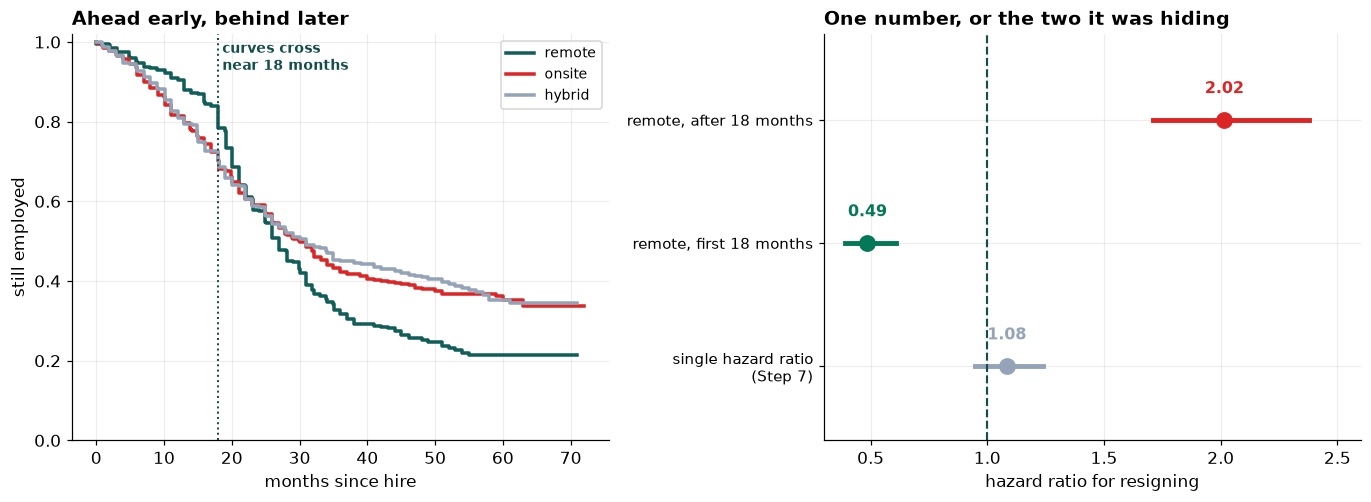

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12.6, 4.7))
for g, c, lab in [("remote", TL, "remote"), ("onsite", RD, "onsite"), ("hybrid", MUT, "hybrid")]:
    s = d[d.work_mode == g]
    k = KaplanMeierFitter().fit(s.tenure_months, s.left)
    ax[0].step(k.survival_function_.index, k.survival_function_.values[:,0], lw=2.3, color=c, label=lab)
ax[0].axvline(18, color=DK, lw=1.3, ls=":")
ax[0].text(18.6, 0.93, "curves cross\nnear 18 months", fontsize=9, color=DK, fontweight="bold")
ax[0].set_xlabel("months since hire"); ax[0].set_ylabel("still employed")
ax[0].legend(fontsize=9); ax[0].set_ylim(0, 1.02)
ax[0].set_title("Ahead early, behind later")

S = ctv.summary
labs  = ["single hazard ratio\n(Step 7)", "remote, first 18 months", "remote, after 18 months"]
est   = [float(cph.summary.loc["mode_remote","exp(coef)"]),
         float(S.loc["remote_first18","exp(coef)"]), float(S.loc["remote_after18","exp(coef)"])]
lo    = [float(cph.summary.loc["mode_remote","exp(coef) lower 95%"]),
         float(S.loc["remote_first18","exp(coef) lower 95%"]), float(S.loc["remote_after18","exp(coef) lower 95%"])]
hi    = [float(cph.summary.loc["mode_remote","exp(coef) upper 95%"]),
         float(S.loc["remote_first18","exp(coef) upper 95%"]), float(S.loc["remote_after18","exp(coef) upper 95%"])]
cols  = [MUT, GD, RD]
for i, (e, l, h, c) in enumerate(zip(est, lo, hi, cols)):
    ax[1].plot([l, h], [i, i], color=c, lw=3.2)
    ax[1].plot(e, i, "o", color=c, ms=10)
    ax[1].text(e, i+0.22, f"{e:.2f}", ha="center", fontsize=10.5, fontweight="bold", color=c)
ax[1].axvline(1.0, color=DK, lw=1.4, ls="--")
ax[1].set_yticks(range(3)); ax[1].set_yticklabels(labs, fontsize=9.5)
ax[1].set_xlabel("hazard ratio for resigning"); ax[1].set_xlim(0.3, 2.6); ax[1].set_ylim(-0.6, 2.7)
ax[1].set_title("One number, or the two it was hiding")
plt.tight_layout(); plt.show()

**Left.** The three survival curves. Remote sits above onsite for a year and a half and below it thereafter, and the crossing is the reason every single-number summary failed.

**Right.** The hazard ratio as first reported, against the two it was averaging. The dashed line is no effect. The single estimate sits almost on it while the two underneath sit far on either side.

## Step 10 &middot; What dropping the censored rows would have said

In [13]:
lv = d[d.left == 1]
print(f"keeping only the {len(lv)} who resigned discards {len(d)-len(lv)} employees "
      f"({1-len(lv)/len(d):.1%} of the company)\n")
Z = pd.DataFrame({"remote": (lv.work_mode == "remote").astype(float),
                  "hybrid": (lv.work_mode == "hybrid").astype(float),
                  "level": lv.level, "salary_percentile": lv.salary_percentile,
                  "manager_changes": lv.manager_changes})
for dep in ["Sales","Customer Support","Operations","Platform"]:
    Z["dept_"+dep.split()[0].lower()] = (lv.department == dep).astype(float)
r = sm.OLS(lv.tenure_months, sm.add_constant(Z)).fit()
print(f"mean tenure at exit: remote {lv.tenure_months[lv.work_mode=='remote'].mean():.1f} months, "
      f"onsite {lv.tenure_months[lv.work_mode=='onsite'].mean():.1f}")
print(f"regression on leavers only: remote {r.params['remote']:+.2f} months (p {r.pvalues['remote']:.3f})")
print("\nthree analyses, three answers:")
print(f"  leavers only        remote stay {r.params['remote']:+.1f} months LONGER  -> expand remote work")
print(f"  log-rank / Cox      no difference (p {lr2.p_value:.2f}, HR "
      f"{float(cph.summary.loc['mode_remote','exp(coef)']):.2f})  -> the policy is irrelevant")
print(f"  time-varying Cox    HR {float(ctv.summary.loc['remote_first18','exp(coef)']):.2f} then "
      f"{float(ctv.summary.loc['remote_after18','exp(coef)']):.2f}  -> it depends entirely on when")

keeping only the 1375 who resigned discards 1816 employees (56.9% of the company)

mean tenure at exit: remote 22.1 months, onsite 18.0
regression on leavers only: remote +3.83 months (p 0.000)

three analyses, three answers:
  leavers only        remote stay +3.8 months LONGER  -> expand remote work
  log-rank / Cox      no difference (p 0.17, HR 1.08)  -> the policy is irrelevant
  time-varying Cox    HR 0.49 then 2.02  -> it depends entirely on when


**A third wrong answer, and the most confident one yet.** Analyzing only the 1,375 people who resigned throws away 1,816 employees, and among the survivors it looks as though remote workers stayed nearly four months longer, significant at any threshold. That analysis would have gone to the board as evidence for expanding remote work.

It is wrong for the same reason the first one was. The leavers are not a sample of employees, they are a sample of *endings*, and which endings have happened yet depends on when people were hired and how long they were going to last.

Three defensible-looking analyses of the same file recommend expanding remote work, ignoring it, and treating it as a retention risk after the first year. Only the last one used every employee.

## Step 11 &middot; What we would tell the people

In [14]:
print("RETENTION")
print(f"  median tenure                 {med:.0f} months, not the {naive:.0f} currently reported")
print(f"  first-year retention          {float(km.predict(12)):.0%}")
print(f"  two-year retention            {float(km.predict(24)):.0%}")
print()
print("REMOTE WORK")
print(f"  first 18 months               resign at {float(ctv.summary.loc['remote_first18','exp(coef)']):.2f}x the onsite rate")
print(f"  after 18 months               resign at {float(ctv.summary.loc['remote_after18','exp(coef)']):.2f}x")
print(f"  what to do                    keep the policy, and act at the 18-month mark")
print()
print("DEPARTMENTS")
print(f"  worst retention               Customer Support, "
      f"{float(cph.summary.loc['dept_customer','exp(coef)']):.2f}x Engineering")
print(f"  Platform                      {float(cph.summary.loc['dept_platform','exp(coef)']):.2f}x Engineering, "
      f"the best in the company, not the worst")

RETENTION
  median tenure                 29 months, not the 19 currently reported
  first-year retention          84%
  two-year retention            58%

REMOTE WORK
  first 18 months               resign at 0.49x the onsite rate
  after 18 months               resign at 2.02x
  what to do                    keep the policy, and act at the 18-month mark

DEPARTMENTS
  worst retention               Customer Support, 1.84x Engineering
  Platform                      0.54x Engineering, the best in the company, not the worst


**Remote work is not the problem and it is not nothing.** It buys eighteen months of unusually good retention and then costs more than it bought. The action that follows is not a policy reversal, it is doing something specific at around eighteen months for remote employees, and measuring whether it moves the second hazard ratio.

**What this does not settle.**

**Involuntary exits were treated as censoring.** Eighty-three people were let go, and the analysis assumes that being let go says nothing about whether that person was about to resign. If the two are related, and they plausibly are, every hazard ratio here is somewhat off. The proper treatment is a competing-risks model that estimates both.

**Eighteen months was chosen by looking at the curves.** The split point was picked after seeing where they crossed, which means the two hazard ratios are a little sharper than an honest out-of-sample estimate would be. A pre-registered split, or a smooth time-varying coefficient, would cost some of that.

**Sales also fails the proportional-hazards test**, mildly. The effect is small enough that a single hazard ratio is a reasonable summary and large enough to mention.

**Nobody hired before 2020 is in this file.** Everything here describes people hired into the company as it has been for six years, and says nothing about the people who were already there.

**This is an observational comparison.** People were not assigned to remote work at random. Whatever leads someone to choose remote also travels with them, and the hazard ratios carry it.